# Image Generation with CFM and CIFAR-10 Dataset

## Harivansh Luchmun

This notebook was built upon the mnist_example.ipynb. Instead of generating images of digits we use the CIFAR dataset to generate images that belong to that dataset such as dogs, cats, and planes

It was rather diffuclt to produce good results without the proper computing power. This notebook was ran on my gaming laptop which contains a GPU, but proved to be insufficient power for running OT-CFM

## Imports

In [1]:
#%load_ext autoreload
#%autoreload 2

import os
import matplotlib.pyplot as plt # For plotting
import torch # For tesors and neural networks
from torchdyn.core import NeuralODE # To solve ODEs

# For loading the dataset and transforming it
from torchvision import datasets, transforms
from torchvision.transforms import ToPILImage
from torchvision.utils import make_grid

# Progress bar for training loops
from tqdm import tqdm

from torchcfm.conditional_flow_matching import * # For conditional flow matching

from torchcfm.models.unet import UNetModel # Convolutional NN used for medical imaging

# Create directory to save trained models
savedir = "models/cifar10"
os.makedirs(savedir, exist_ok=True)

c:\Users\hluch\miniconda3\envs\torchcfm\lib\site-packages\lightning_fabric\__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


## Setting hyperparameters and Manipulating data

In [2]:
# Uses GPU if available
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

batch_size = 128  # Number of samples per batch
n_epochs = 50  # Number of training epochs for OT-CFM
lr = 2e-4  # Learning rate for the optimizer to make sure its not too high
weight_decay = 1e-4  # Regularization to discourage large weights

# Model architecture parameters
model_channels = 64  # Base number of channels in the UNet model
num_res_blocks = 2 

ode_steps = 200  # Number of steps for ODE solver
ode_dt = 1.0 / ode_steps  # Time step size for ODE integration

# Load CIFAR dataset
trainset = datasets.CIFAR10(
    "../data",
    train=True,
    download=True, 
    # Transforms images to be tensosr with pixel values normalized to [-1, 1]
    transform=transforms.Compose([
        transforms.ToTensor(), 
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]),
)

# Create DataLoader
train_loader = torch.utils.data.DataLoader(
    trainset, 
    batch_size=batch_size, 
    shuffle=True,  # Shuffle data 
    drop_last=True  # Drop last incomplete batch to maintain consistent batch size
)

Files already downloaded and verified


In [3]:
#################################
#            OT-CFM
#

sigma = 0.0

# Initialize the Unet model to learn the flow
model = UNetModel(
    dim=(3, 32, 32), # RGB images of size 32 by 32
    num_channels=model_channels,  # Base channel width
    num_res_blocks=num_res_blocks
).to(device)

# Adam optimizer: Efficient convergence and smooth gradients
optimizer = torch.optim.Adam(
    model.parameters(), lr=lr, weight_decay=weight_decay
)

# Gradually decreases learning rate
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)


# Finds the minimal cost transport plan instead of random pairings
FM = ExactOptimalTransportConditionalFlowMatcher(sigma=sigma)

# ODE solver
node = NeuralODE(model, solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4)

## Training The Model

In [4]:
# Training loop for OT-CFM
for epoch in range(n_epochs):

    # Iterate through all batches in training set
    for i, data in tqdm(enumerate(train_loader)):
        
        optimizer.zero_grad() # Reset gradients
        x1 = data[0].to(device) #Moving data to device
        x0 = torch.randn_like(x1) # Sample noise batch with same shape as data
        
        #Takes a time t, a sample noise point x0, and a data point x1,
        # then samples an x_t from the OT path, and gives the true velocity
        t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1)
        vt = model(t, xt) # Model velocity prediction
        loss = torch.mean((vt - ut) ** 2) # FM objective loss function
        loss.backward() # Backpropogates gradients 
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Doesnt let gradients get too big
        optimizer.step() # Update model parameters
    scheduler.step() #update learning rate

390it [01:47,  3.62it/s]
390it [01:37,  4.02it/s]
390it [01:33,  4.16it/s]
390it [01:33,  4.16it/s]
390it [01:40,  3.90it/s]
390it [01:40,  3.88it/s]
390it [01:40,  3.88it/s]
390it [01:40,  3.86it/s]
390it [01:40,  3.87it/s]
390it [01:40,  3.87it/s]
390it [01:40,  3.88it/s]
390it [01:41,  3.85it/s]
390it [01:40,  3.87it/s]
390it [01:41,  3.86it/s]
390it [01:37,  3.99it/s]
390it [01:33,  4.17it/s]
390it [01:33,  4.17it/s]
390it [01:33,  4.17it/s]
390it [01:33,  4.17it/s]
390it [01:33,  4.17it/s]
390it [01:33,  4.17it/s]
390it [01:33,  4.17it/s]
390it [01:33,  4.17it/s]
390it [01:33,  4.17it/s]
390it [01:33,  4.17it/s]
390it [01:33,  4.17it/s]
390it [01:33,  4.17it/s]
390it [01:33,  4.17it/s]
390it [01:33,  4.17it/s]
390it [01:33,  4.17it/s]
390it [01:33,  4.17it/s]
390it [01:33,  4.17it/s]
390it [01:33,  4.17it/s]
390it [01:33,  4.17it/s]
390it [01:33,  4.17it/s]
390it [01:33,  4.17it/s]
390it [01:33,  4.17it/s]
390it [01:33,  4.17it/s]
390it [01:33,  4.17it/s]
390it [01:33,  4.17it/s]


## Generating New Samples

(np.float64(-0.5), np.float64(319.5), np.float64(319.5), np.float64(-0.5))

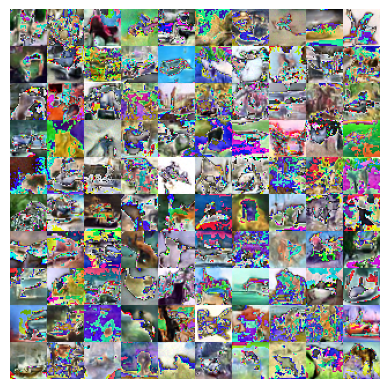

In [6]:
# Generate samples using the model
with torch.no_grad():
    traj = node.trajectory(
        torch.randn(100, 3, 32, 32, device=device), # Take 100 random noise samples
        t_span=torch.linspace(0, 1, ode_steps, device=device), # Splits interval from 0-1 into 200 pieces
    )
grid = make_grid(
    traj[-1, :100].view([-1, 3, 32, 32]).clip(-1, 1),  # Looks at final state 
    value_range=(-1, 1),  # Value range for normalization
    padding=0, 
    nrow=10  # Arrange in 10x10 grid
)
img = ToPILImage()(grid) # Convert grid tensor to PIL image
plt.imshow(img)
plt.axis("off")  # Hide axes for cleaner visualization

The results are still not very good images, but we can start to see some forming of interpratable images. We can see some automobiles more distinctly as well as features of animals. With training times or more epochs we can achieve better images.